Random Forest Accuracy: 0.9777777777777777
Random Forest Training Time: 1.2892935276031494
Random Forest Prediction Time: 0.08319211006164551
Out-of-Bag Score: 0.9673826571201273


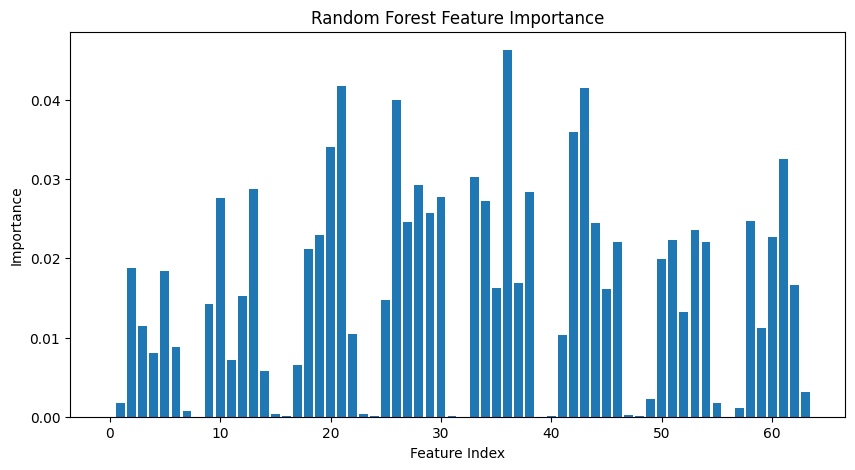

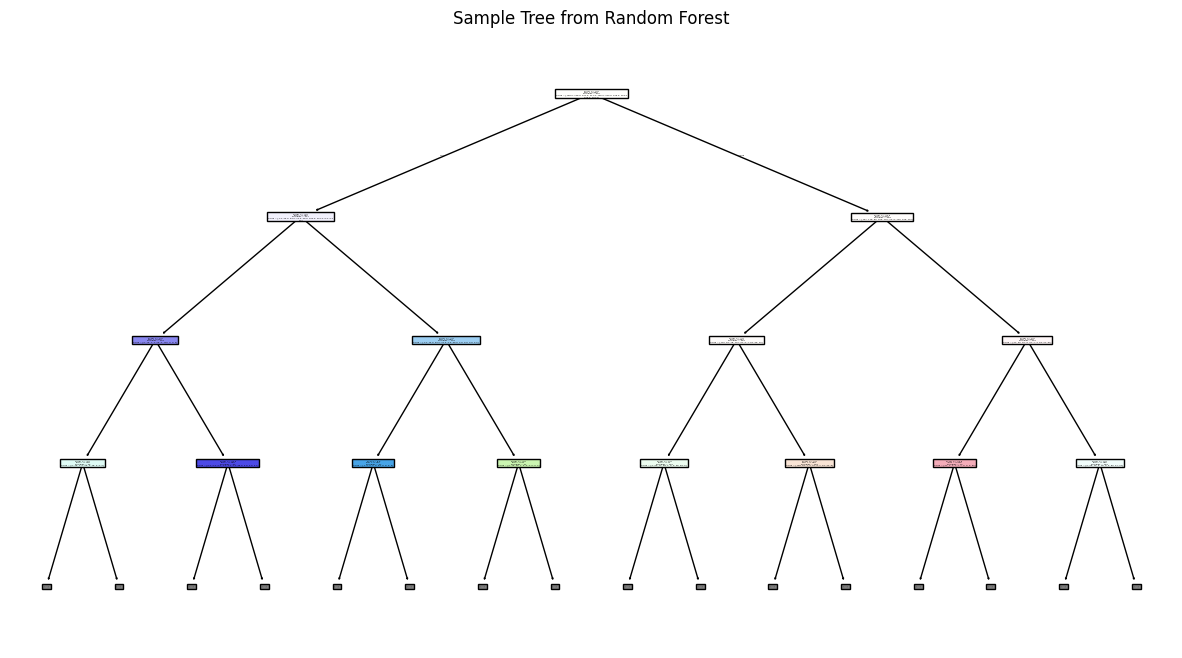


AdaBoost Accuracy: 0.7981481481481482
AdaBoost Training Time: 1.2217247486114502
AdaBoost Prediction Time: 0.1555647850036621


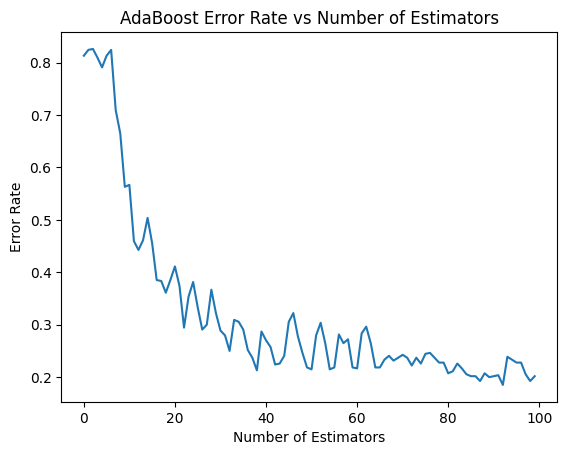


----- Performance Comparison -----
Random Forest Accuracy: 0.9777777777777777
AdaBoost Accuracy: 0.7981481481481482
Random Forest Training Time: 1.2892935276031494
AdaBoost Training Time: 1.2217247486114502
Random Forest Prediction Time: 0.08319211006164551
AdaBoost Prediction Time: 0.1555647850036621


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# -------------------------------
# Load Digits Dataset
# -------------------------------

digits = load_digits()
X = digits.data
y = digits.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# =================================================
# PART A – RANDOM FOREST
# =================================================

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    oob_score=True,
    bootstrap=True,
    random_state=42
)

start = time.time()
rf.fit(X_train, y_train)
train_time_rf = time.time() - start

start = time.time()
rf_pred = rf.predict(X_test)
predict_time_rf = time.time() - start

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)
print("Random Forest Training Time:", train_time_rf)
print("Random Forest Prediction Time:", predict_time_rf)
print("Out-of-Bag Score:", rf.oob_score_)

# -------------------------------
# Feature Importance
# -------------------------------

importances = rf.feature_importances_

plt.figure(figsize=(10,5))
plt.bar(range(len(importances)), importances)
plt.title("Random Forest Feature Importance")
plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.show()

# -------------------------------
# Visualize one tree
# -------------------------------

from sklearn.tree import plot_tree

plt.figure(figsize=(15,8))
plot_tree(rf.estimators_[0], filled=True, max_depth=3)
plt.title("Sample Tree from Random Forest")
plt.show()


# =================================================
# PART B – ADABOOST
# =================================================

stump = DecisionTreeClassifier(max_depth=1)

ada = AdaBoostClassifier(
    estimator=stump,
    n_estimators=100,
    learning_rate=1,
    random_state=42
)

start = time.time()
ada.fit(X_train, y_train)
train_time_ada = time.time() - start

start = time.time()
ada_pred = ada.predict(X_test)
predict_time_ada = time.time() - start

ada_accuracy = accuracy_score(y_test, ada_pred)

print("\nAdaBoost Accuracy:", ada_accuracy)
print("AdaBoost Training Time:", train_time_ada)
print("AdaBoost Prediction Time:", predict_time_ada)

# -------------------------------
# Error vs Estimators
# -------------------------------

errors = []

for y_pred in ada.staged_predict(X_test):
    errors.append(1 - accuracy_score(y_test, y_pred))

plt.plot(errors)
plt.title("AdaBoost Error Rate vs Number of Estimators")
plt.xlabel("Number of Estimators")
plt.ylabel("Error Rate")
plt.show()


# =================================================
# PART C – COMPARISON
# =================================================

print("\n----- Performance Comparison -----")

print("Random Forest Accuracy:", rf_accuracy)
print("AdaBoost Accuracy:", ada_accuracy)

print("Random Forest Training Time:", train_time_rf)
print("AdaBoost Training Time:", train_time_ada)

print("Random Forest Prediction Time:", predict_time_rf)
print("AdaBoost Prediction Time:", predict_time_ada)